Wine: The dataset is about wine quality including red
and white wine samples. The features include objective tests
(e.g. PH values) and the output is based on sensory data.
The labels are given by experts with grades between 0 (very
bad) and 10 (very excellent). There are 1599 records for the
red wine and 4898 for the white wine. We use the quality
prediction problem for the white wine as the source task and
the quality prediction problem for red wine as the target task

In [1]:
from ucimlrepo import fetch_ucirepo 
import matplotlib.pyplot as plt
import gpflow as gpf
import sys
import tensorflow as tf
import numpy as np
sys.path.append("/home/janneke/at-gpflow")
from atmodel import AdaptiveTransferGPR
from atkernel import TransferKernel
  
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  




2025-07-14 14:20:21.499997: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-14 14:20:21.502115: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-14 14:20:21.526814: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-14 14:20:21.526862: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-14 14:20:21.528078: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [36]:
from sklearn.model_selection import train_test_split
# data (as pandas dataframes) 
Xc = wine_quality.data.original 
X = wine_quality.data.features
print(len(X))
y = wine_quality.data.targets
inds = np.random.choice(np.arange(0, len(X)), replace=False, size=2000)

X = X.to_numpy()[inds]
y = y.to_numpy()[inds]
Xc = Xc.iloc[inds]
filter_target = Xc["color"] == "red"
filter_source = Xc["color"] == "white"
Sx, Sy = X[filter_source], y[filter_source].reshape(-1, 1).astype(float)
Tx, Ty = X[filter_target], y[filter_target].reshape(-1, 1).astype(float)

Tx_train, Tx_test, Ty_train, Ty_test = train_test_split(Tx, Ty, test_size=0.20)   # no sequence right?

print("train", len(Sx), "train_target", len(Tx_train))
print("test", len(Tx))

6497
train 1495 train_target 404
test 505


In [37]:
at_gpr = AdaptiveTransferGPR((Sx, Sy), (Tx_train, Ty_train), gpf.kernels.RBF())

print("Training loss value before training:", at_gpr.training_loss().numpy())
opt = gpf.optimizers.Scipy()
opt.minimize(at_gpr.training_loss, at_gpr.trainable_variables)
gpf.utilities.print_summary(at_gpr)
print("Training loss value after training:", at_gpr.training_loss().numpy())

Training loss value before training: 3144.784874077361


2025-07-14 16:10:25.976415: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2025-07-14 16:10:26.201858: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2025-07-14 16:10:26.426497: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2025-07-14 16:10:26.650399: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular output with NaNs.
2025-07-14 16:10:26.879585: W tensorflow/core/kernels/linalg/cholesky_op.cc:56] Cholesky decomposition was not successful. Eigen::LLT failed with error code 1. Filling lower-triangular out

╒════════════════════════════════════════════════════════╤═══════════╤══════════════════╤═════════╤═════════════╤═════════╤═════════╤═════════╕
│ name                                                   │ class     │ transform        │ prior   │ trainable   │ shape   │ dtype   │   value │
╞════════════════════════════════════════════════════════╪═══════════╪══════════════════╪═════════╪═════════════╪═════════╪═════════╪═════════╡
│ AdaptiveTransferGPR.kernel.mu                          │ Parameter │ Exp              │         │ True        │ ()      │ float64 │ 3.98637 │
├────────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼─────────┤
│ AdaptiveTransferGPR.kernel.b                           │ Parameter │ Exp              │         │ True        │ ()      │ float64 │ 0.30797 │
├────────────────────────────────────────────────────────┼───────────┼──────────────────┼─────────┼─────────────┼─────────┼─────────┼───

plt.plot(Ty_test)

In [38]:
Ty_test_std = (Ty_test - Ty_test.mean()) / Ty_test.std()

20.96247205575417


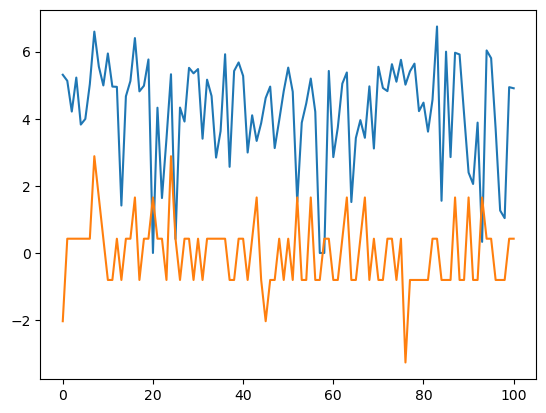

In [39]:
fmean, fvar = at_gpr.predict_f(Tx_test)
fmean = fmean - at_gpr.mean_function(Tx_test)
print(np.mean((Ty_test_std - fmean) ** 2) / np.var(Ty_test_std))
plt.plot(fmean)
plt.plot(Ty_test_std)